In [1]:
import sys
sys.path.insert(0, "/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Data Generation")

from sigma_sweep import rho_for_run

/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/scvi/__init__.py:31: DeprecationWarning: scvi is deprecated, please uninstall scvi via `pip uninstall scvi` and install the new scvi-tools package at github.com/YosefLab/scvi-tools
  warnings.warn(deprecation_msg, DeprecationWarning)


## Test Run for Original Decipher
testing decipher_bc at sigma=0.5 and seed =0  
plots ground truth vs learned pseudotime  
plots ground truth vs learned z space  

Epoch 114 (batch 24/24) | | train elbo: 33.34 (last epoch: 33.61) | val ll: 44.03:  11%|█▏        | 114/1000 [00:31<04:06,  3.60it/s]2026-07-17 08:05:40,828 | INFO : Early stopping has been triggered.
2026-07-17 08:05:40,830 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-07-17 08:05:40,830 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-07-17 08:05:40,834 | INFO : Saving decipher model with run_id 2026-07-17-08-05-40-simple-green-weight.


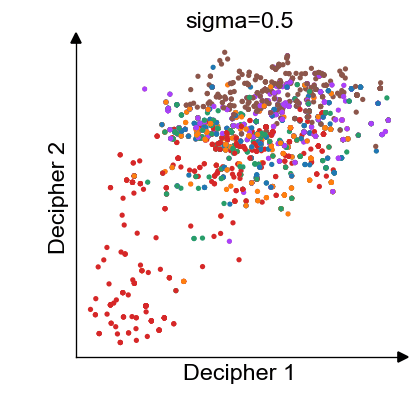

/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
2026-07-17 08:05:41,134 | INFO : Clustering cells using scanpy Leiden algorithm.
2026-07-17 08:05:41,135 | INFO : Step 1: Computing neighbors with `sc.pp.neighbors`, with the representation decipher_z.
/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
2026-07-17 08:05:43,464 | INFO : Step 2: Computing clusters with `sc.tl.leiden`, and resolution 0.05.
/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/decipher/tools/trajectory_inference.py:225: FutureWarning: In the future, the default backend for leiden will be i

rho = 0.9359
ground truth: /Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Data Generation/../Simulated Adata/v-to-z/0717_vz_0.06_-0.07_0.32_0.05_-0.27.h5ad
trained:      /Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Data Generation/../Simulated Adata/v-to-z/trained/decipher/sigma0.5_seed0_decipher.h5ad


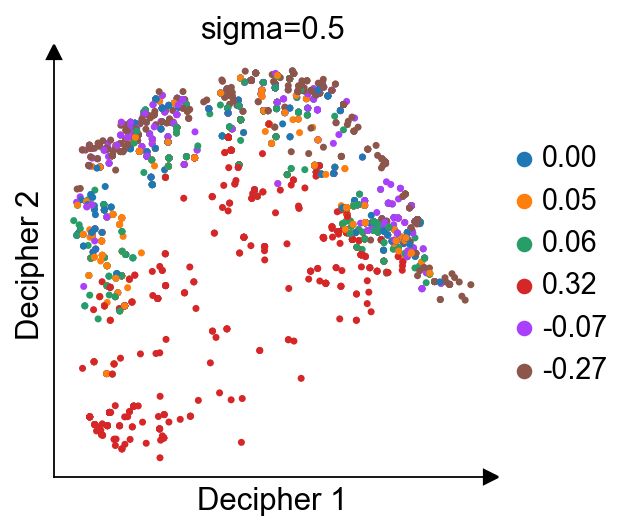

In [2]:
rho, gt_path, trained_path, adata = rho_for_run(sigma=0.5, seed=0, batch_aware=False)
print(f"rho = {rho:.4f}")
print(f"ground truth: {gt_path}")
print(f"trained:      {trained_path}")

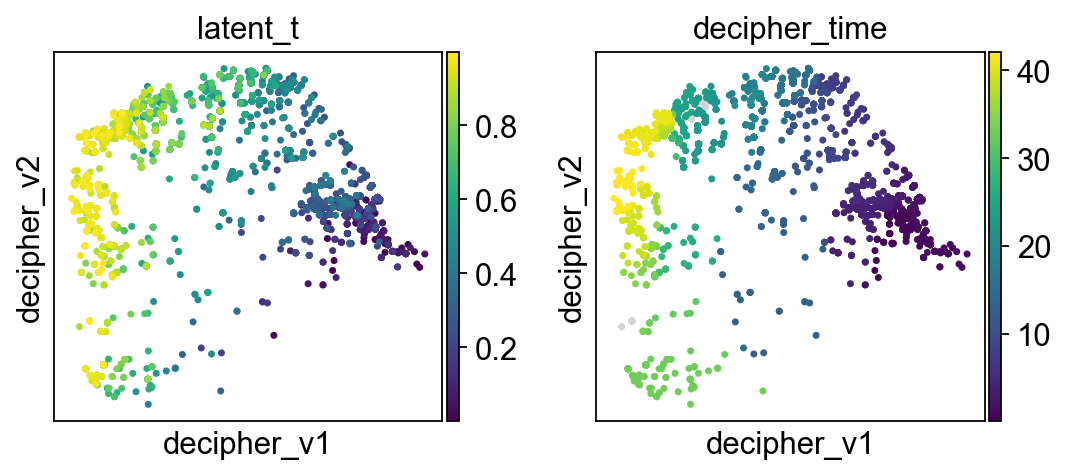

rho = 0.9359


In [3]:
import scanpy as sc

sc.pl.embedding(adata, basis="decipher_v", color=["latent_t", "decipher_time"])
print(f"rho = {rho:.4f}")

sigma=0.5  ground truth z silhouette (by batch) = 0.0203
sigma=0.5  learned decipher_z silhouette (by batch) = -0.0205


/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


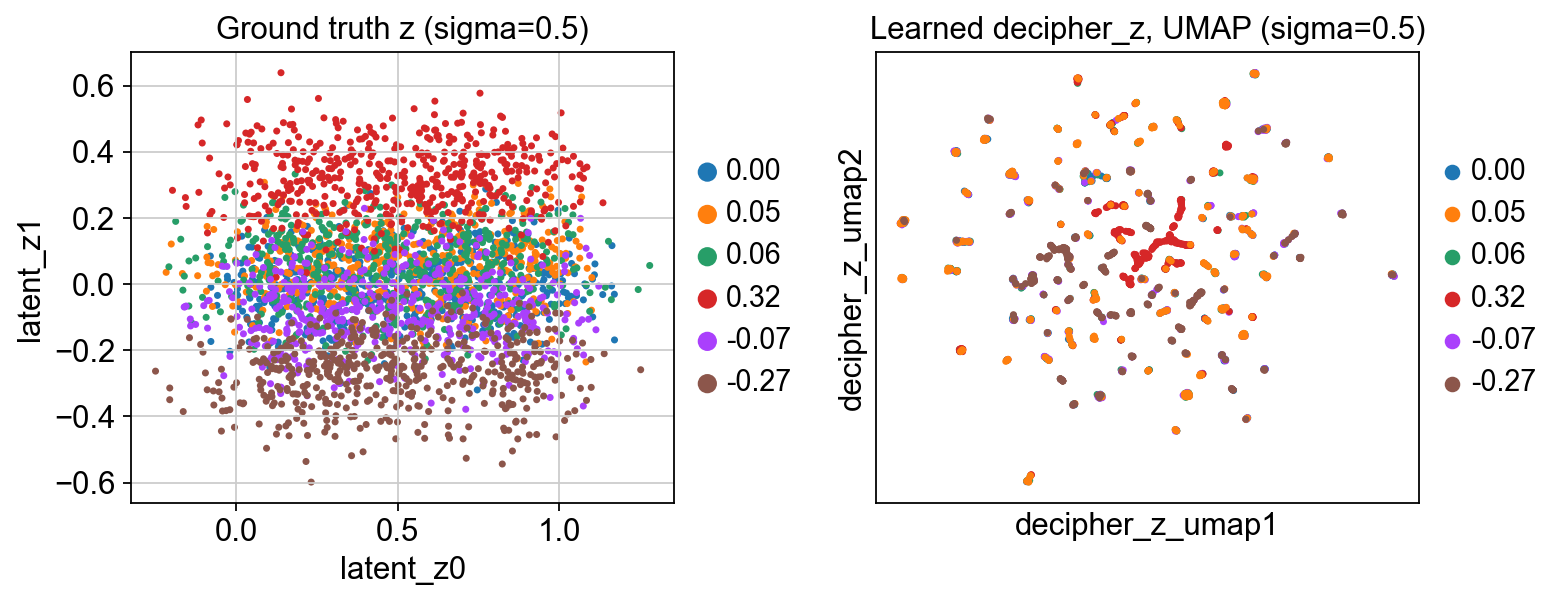

In [4]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# --- Quantitative: silhouette score directly on raw feature space (no projection) ---
batch_labels = adata.obs["batch"].astype(str)

sil_ground_truth = silhouette_score(
    adata.obs[["latent_z0", "latent_z1"]].values, batch_labels,
    sample_size=min(5000, adata.n_obs), random_state=42,
)
sil_learned = silhouette_score(
    adata.obsm["decipher_z"], batch_labels,
    sample_size=min(5000, adata.n_obs), random_state=42,
)
print(f"sigma={0.5}  ground truth z silhouette (by batch) = {sil_ground_truth:.4f}")
print(f"sigma={0.5}  learned decipher_z silhouette (by batch) = {sil_learned:.4f}")

# --- Qualitative: ground truth z (already 2D) vs. UMAP of learned decipher_z ---
sc.pp.neighbors(adata, use_rep="decipher_z", random_state=42)
sc.tl.umap(adata, random_state=42)
adata.obsm["decipher_z_umap"] = adata.obsm["X_umap"]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
sc.pl.scatter(adata, x="latent_z0", y="latent_z1", color="batch",
              ax=axes[0], show=False, title=f"Ground truth z (sigma={0.5})")
sc.pl.embedding(adata, basis="decipher_z_umap", color="batch",
                ax=axes[1], show=False, title=f"Learned decipher_z, UMAP (sigma={0.5})")
plt.tight_layout()
plt.show()

## Test Run for Decipher_BC
testing decipher_bc at sigma=0.5 and seed =0  
plots ground truth vs learned pseudotime  
plots ground truth vs learned z space  

Epoch 96 (batch 24/24) | | train elbo: 34.03 (last epoch: 33.99) | val ll: 43.49:  10%|▉         | 96/1000 [00:28<04:23,  3.43it/s]2026-07-17 07:19:02,743 | INFO : Early stopping has been triggered.
2026-07-17 07:19:02,746 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-07-17 07:19:02,746 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-07-17 07:19:02,749 | INFO : Saving decipher model with run_id 2026-07-17-07-19-02-prepared-livid-milk.


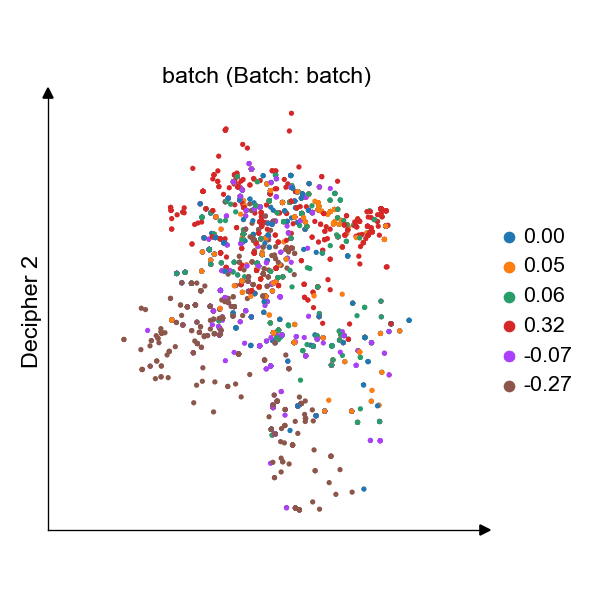

/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
2026-07-17 07:19:03,129 | INFO : Clustering cells using scanpy Leiden algorithm.
2026-07-17 07:19:03,129 | INFO : Step 1: Computing neighbors with `sc.pp.neighbors`, with the representation decipher_z.
/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
2026-07-17 07:19:05,580 | INFO : Step 2: Computing clusters with `sc.tl.leiden`, and resolution 0.05.
/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/concat-v-to-z/decipher_vz/tools/trajectory_inference.py:225: FutureWarning: In the future, the default backend for

rho = 0.9376
ground truth: /Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Data Generation/../Simulated Adata/v-to-z/0717_vz_0.06_-0.07_0.32_0.05_-0.27.h5ad
trained:      /Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Data Generation/../Simulated Adata/v-to-z/trained/decipher_bc/sigma0.5_seed0_decipher_bc.h5ad


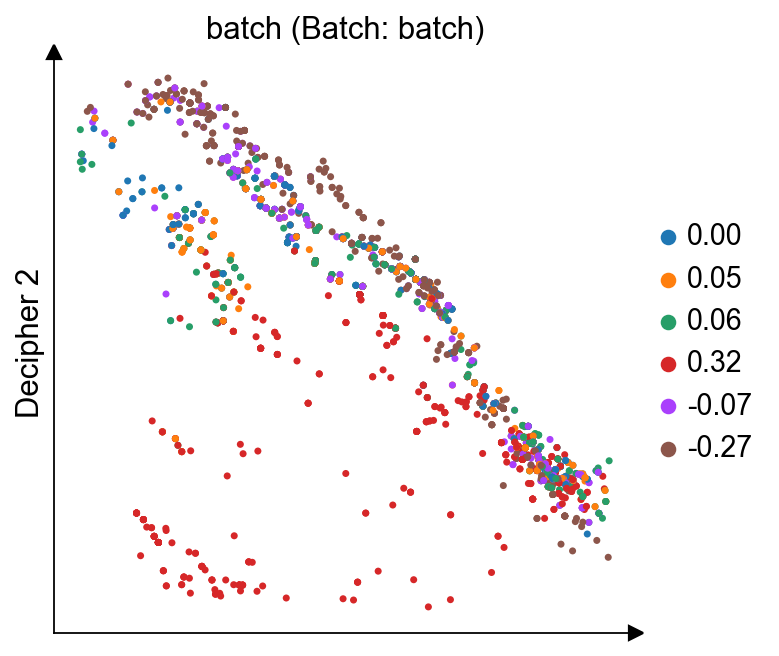

In [2]:
rho, gt_path, trained_path, adata = rho_for_run(sigma=0.5, seed=0, batch_aware=True)
print(f"rho = {rho:.4f}")
print(f"ground truth: {gt_path}")
print(f"trained:      {trained_path}")

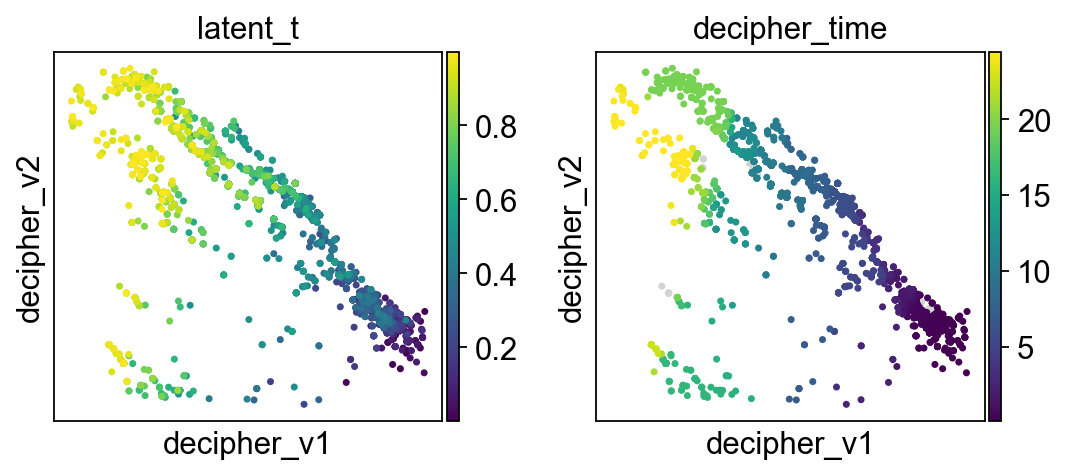

rho = 0.9376


In [5]:
import scanpy as sc

sc.pl.embedding(adata, basis="decipher_v", color=["latent_t", "decipher_time"])
print(f"rho = {rho:.4f}")

sigma=0.5  ground truth z silhouette (by batch) = 0.0203
sigma=0.5  learned decipher_z silhouette (by batch) = 0.0026


/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


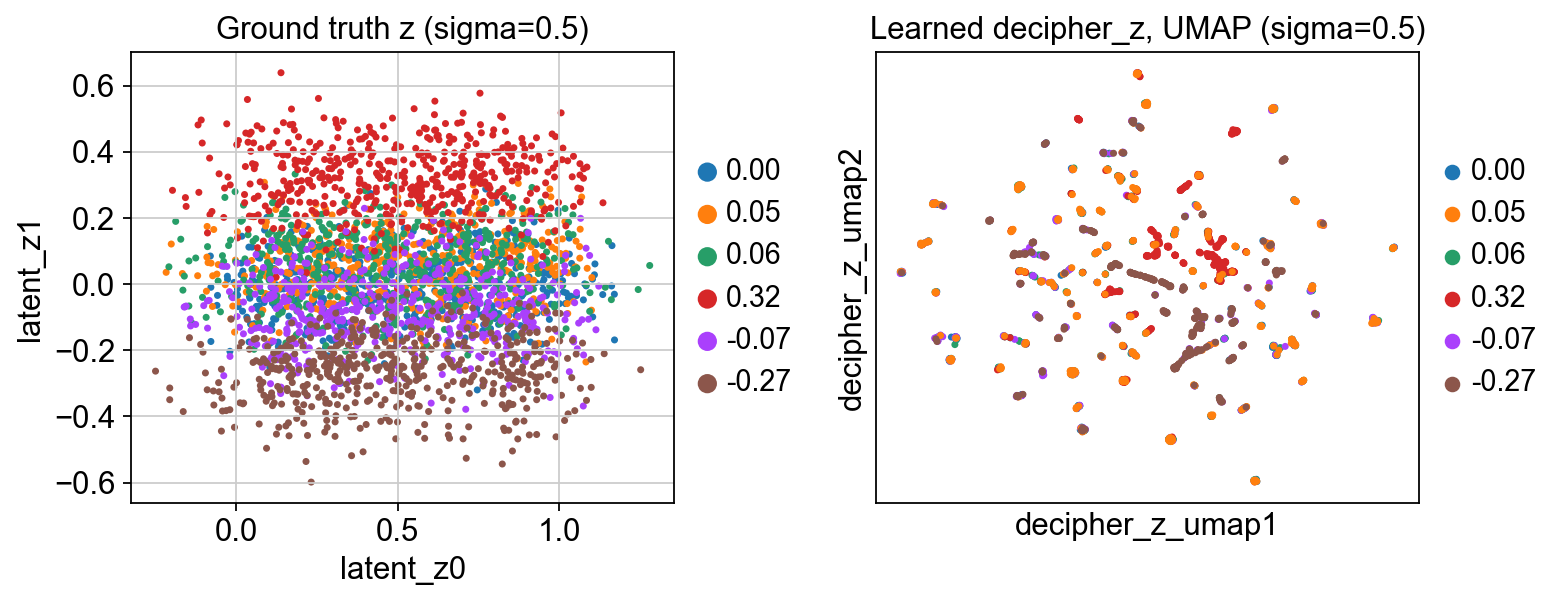

In [ ]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# --- Quantitative: silhouette score directly on raw feature space (no projection) ---
batch_labels = adata.obs["batch"].astype(str)

sil_ground_truth = silhouette_score(
    adata.obs[["latent_z0", "latent_z1"]].values, batch_labels,
    sample_size=min(5000, adata.n_obs), random_state=42,
)
sil_learned = silhouette_score(
    adata.obsm["decipher_z"], batch_labels,
    sample_size=min(5000, adata.n_obs), random_state=42,
)
print(f"sigma={0.5}  ground truth z silhouette (by batch) = {sil_ground_truth:.4f}")
print(f"sigma={0.5}  learned decipher_z silhouette (by batch) = {sil_learned:.4f}")

# --- Qualitative: ground truth z (already 2D) vs. UMAP of learned decipher_z ---
sc.pp.neighbors(adata, use_rep="decipher_z", random_state=42)
sc.tl.umap(adata, random_state=42)
adata.obsm["decipher_z_umap"] = adata.obsm["X_umap"]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
sc.pl.scatter(adata, x="latent_z0", y="latent_z1", color="batch",
              ax=axes[0], show=False, title=f"Ground truth z (sigma={0.5})")
sc.pl.embedding(adata, basis="decipher_z_umap", color="batch",
                ax=axes[1], show=False, title=f"Learned decipher_z, UMAP (sigma={0.5})")
plt.tight_layout()
plt.show()

In [ ]:
# import pandas as pd

# records = []
# for batch_aware, model_name in [(True, "Decipher-BC"), (False, "Base Decipher")]:
#     for sigma in [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]:
#         for seed in [0, 1, 2, 3, 4]:
#             rho, gt_path, trained_path, adata = rho_for_run(sigma=sigma, seed=seed, batch_aware=batch_aware)
#             records.append({
#                 "model": model_name,
#                 "sigma": sigma,
#                 "seed": seed,
#                 "rho": rho,
#                 "ground_truth_h5ad": gt_path,
#                 "trained_h5ad": trained_path,
#             })

# results_df = pd.DataFrame(records)
# results_df.to_csv("sigma_sweep_results.csv", index=False)
# results_df